# **Suppliment Sales Dataset**



## **Imoprting Libraries**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## **Load Dataset**

In [ ]:
import pandas as pd
df = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vS0hdl7036eZ7i_anwtzAkK7939pai6NSCo-VL9xeD0zzr1E-JqPiGBTl-qGfsRmA/pub?gid=1016598926&single=true&output=csv")
df

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,6/1/2020,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,6/1/2020,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,6/1/2020,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,6/1/2020,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,6/1/2020,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb
...,...,...,...,...,...,...,...,...,...,...
4379,31/3/2025,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb
4380,31/3/2025,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart
4381,31/3/2025,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb
4382,31/3/2025,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon


In [ ]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,6/1/2020,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,6/1/2020,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,6/1/2020,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,6/1/2020,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,6/1/2020,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4384 non-null   object 
 1   Product Name    4384 non-null   object 
 2   Category        4384 non-null   object 
 3   Units Sold      4384 non-null   int64  
 4   Price           4384 non-null   float64
 5   Revenue         4384 non-null   float64
 6   Discount        4384 non-null   float64
 7   Units Returned  4384 non-null   int64  
 8   Location        4384 non-null   object 
 9   Platform        4384 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 342.6+ KB


In [ ]:
df.describe()

,Units Sold,Price,Revenue,Discount,Units Returned
count,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,150.200274,34.781229,5226.569446,0.124398,1.531478
std,12.396099,14.198309,2192.491946,0.071792,1.258479
min,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,158.000000,46.712500,7009.960000,0.190000,2.000000
max,194.000000,59.970000,10761.850000,0.250000,8.000000


In [ ]:
df.isnull().sum()

,0
Date,0
Product Name,0
Category,0
Units Sold,0
Price,0
Revenue,0
Discount,0
Units Returned,0
Location,0
Platform,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## **Clean Dataset**

In [ ]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

if df.index.name == 'Date':
    df.reset_index(inplace=True)

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df.set_index("Date", inplace=True)

## **Monthly Sales Trend**





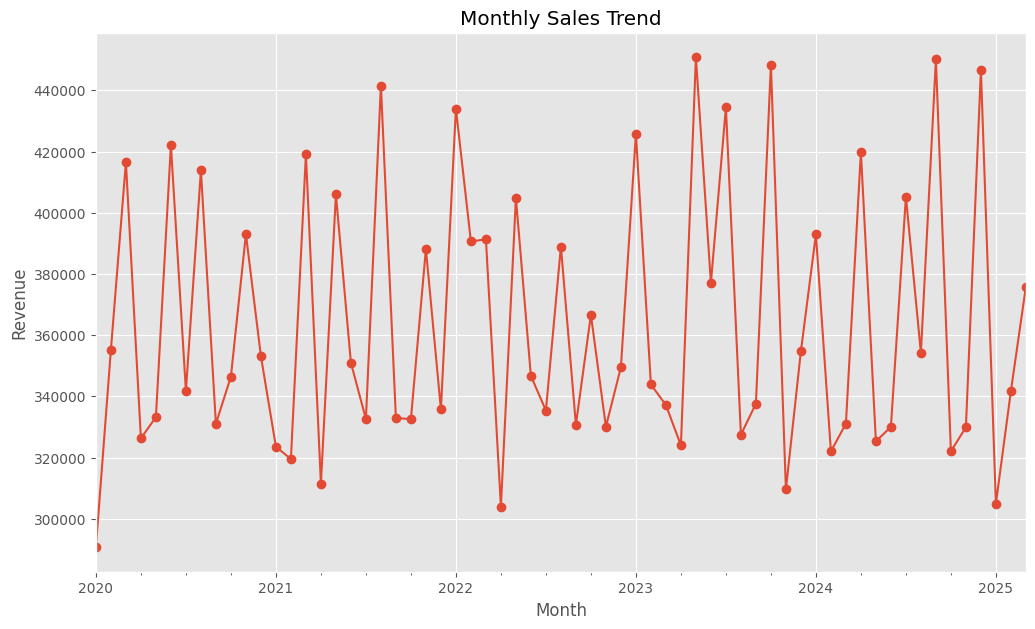

In [ ]:
monthly_sales = df.groupby(df.index.to_period("M"))["Revenue"].sum()
monthly_sales.plot(figsize=(12, 7), marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## **Sales By Category**


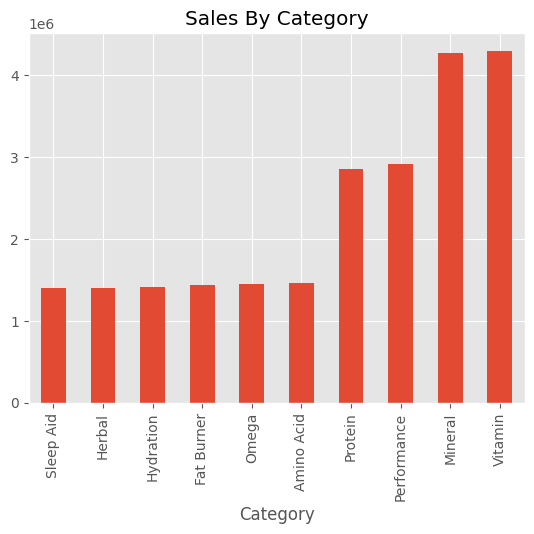

In [ ]:
category = df.groupby("Category")["Revenue"].sum().sort_values()
category.plot(kind='bar')
plt.title("Sales By Category")
plt.show()

## **Top 10 Products in Demand**

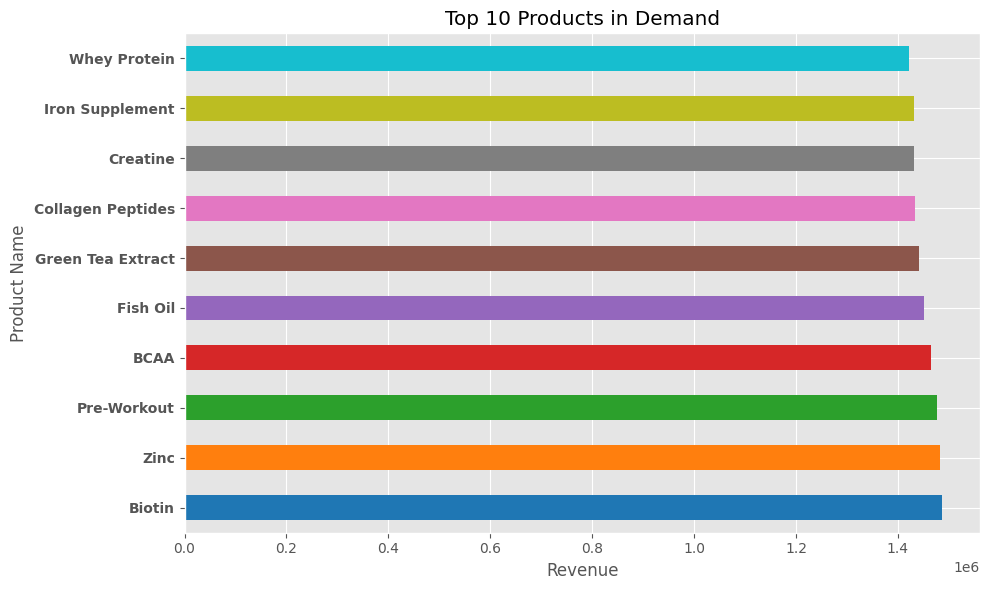

In [ ]:
top_products = df.groupby("Product Name")["Revenue"].sum().nlargest(10)
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 6))
top_products.plot(kind='barh', color=colors, ax=ax)

plt.title("Top 10 Products in Demand")
plt.xlabel("Revenue")
plt.ylabel("Product Name")


for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(10)

plt.tight_layout()
plt.show()

## **Region-wise Sales**

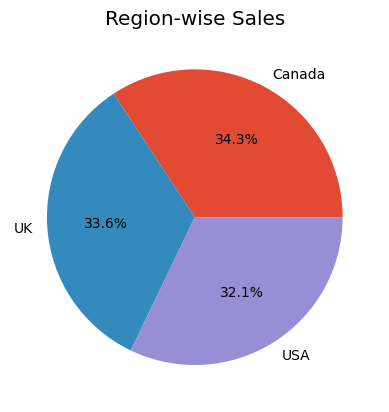

In [ ]:
region = df.groupby("Location")["Revenue"].sum()
region.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Region-wise Sales")
plt.show()

## **Correlation Heatmap**

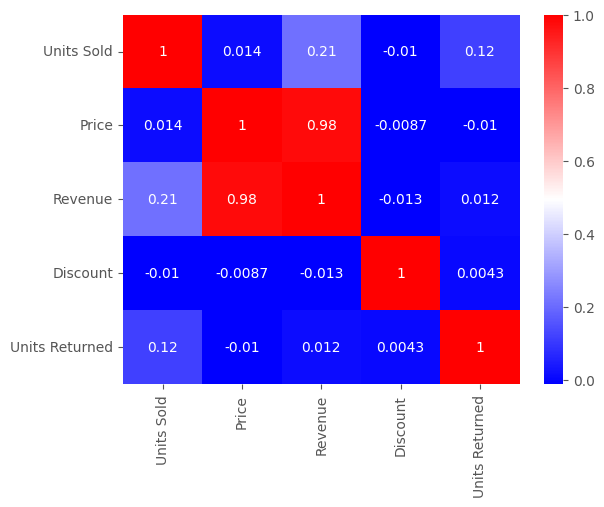

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='bwr')
plt.show()